# Лабораторная работа
## Тема: Нейронная сеть прямого распространения для классификации

### 1. Название и краткая информация о сдаваемом методе

Нейронная сеть прямого распространения (feed-forward neural network) — это модель, в которой сигнал проходит от входного слоя через один или несколько скрытых слоев к выходному слою. Веса нейронов настраиваются в процессе обучения методом обратного распространения ошибки, а нелинейные функции активации позволяют модели находить сложные зависимости между признаками и целевым классом.

В данной лабораторной работе используется многослойный перцептрон `MLPClassifier` для бинарной классификации грибов. Задача модели — по описательным признакам гриба определить, относится ли он к съедобным или ядовитым.
        


### 2. Блок с используемыми библиотеками

В работе используются `pandas` и `numpy` для обработки данных, `matplotlib` и `seaborn` для визуализации, а также инструменты `scikit-learn` для кодирования категориальных признаков, разбиения выборки, обучения нейронной сети и оценки качества классификации.
        


In [2]:
import os
import warnings
from pathlib import Path
from urllib.request import urlretrieve

os.environ["LOKY_MAX_CPU_COUNT"] = "4"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import learning_curve, train_test_split, validation_curve
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

sns.set_theme(style="whitegrid", font_scale=1.0)
RANDOM_STATE = 42
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data"
COLUMN_NAMES = ['class', 'cap_shape', 'cap_surface', 'cap_color', 'bruises', 'odor', 'gill_attachment', 'gill_spacing', 'gill_size', 'gill_color', 'stalk_shape', 'stalk_root', 'stalk_surface_above_ring', 'stalk_surface_below_ring', 'stalk_color_above_ring', 'stalk_color_below_ring', 'veil_type', 'veil_color', 'ring_number', 'ring_type', 'spore_print_color', 'population', 'habitat']


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)
        


### 3. Блок с описанием и демонстрацией используемого датасета

Для лабораторной работы выбран датасет **Mushroom** из UCI Machine Learning Repository. Он содержит **8124 объекта** и описывает грибы по внешним признакам: форма и цвет шляпки, запах, параметры пластинок, кольца, спорового отпечатка, место произрастания и другие характеристики.

Целевая переменная `class` имеет два класса:

- `edible` — съедобный гриб;
- `poisonous` — ядовитый гриб.


In [3]:
candidate_paths = [
    Path("agaricus-lepiota.data"),
    Path("block-4/pca/agaricus-lepiota.data"),
    Path("agaricus-lepiota.data"),
    Path(r"/block-4/neural-network/agaricus-lepiota.data"),
    Path("/content/agaricus-lepiota.data"),
    Path("/mnt/data/agaricus-lepiota.data"),
]

for path in candidate_paths:
    if path.exists():
        data_path = path
        break
else:
    data_path = Path("agaricus-lepiota.data")
    print("Локальный файл датасета не найден. Выполняется загрузка с UCI...")
    urlretrieve(DATA_URL, data_path)

df = pd.read_csv(data_path, header=None, names=COLUMN_NAMES)
df = df.replace({"?": "unknown"})

class_labels = {"e": "edible", "p": "poisonous"}
df["class_label"] = df["class"].map(class_labels)

print(f"Используемый файл: {data_path}")
print(f"Размер датасета: {df.shape[0]} строк и {df.shape[1]} столбца")
display(df.head(10))
        


Используемый файл: agaricus-lepiota.data
Размер датасета: 8124 строк и 24 столбца


,class,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class_label
0,p,x,s,n,t,p,f,c,n,k,...,w,w,p,w,o,p,k,s,u,poisonous
1,e,x,s,y,t,a,f,c,b,k,...,w,w,p,w,o,p,n,n,g,edible
2,e,b,s,w,t,l,f,c,b,n,...,w,w,p,w,o,p,n,n,m,edible
3,p,x,y,w,t,p,f,c,n,n,...,w,w,p,w,o,p,k,s,u,poisonous
4,e,x,s,g,f,n,f,w,b,k,...,w,w,p,w,o,e,n,a,g,edible
5,e,x,y,y,t,a,f,c,b,n,...,w,w,p,w,o,p,k,n,g,edible
6,e,b,s,w,t,a,f,c,b,g,...,w,w,p,w,o,p,k,n,m,edible
7,e,b,y,w,t,l,f,c,b,n,...,w,w,p,w,o,p,n,s,m,edible
8,p,x,y,w,t,p,f,c,n,p,...,w,w,p,w,o,p,k,v,g,poisonous
9,e,b,s,y,t,a,f,c,b,g,...,w,w,p,w,o,p,k,s,m,edible


Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap_shape                 8124 non-null   str  
 2   cap_surface               8124 non-null   str  
 3   cap_color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill_attachment           8124 non-null   str  
 7   gill_spacing              8124 non-null   str  
 8   gill_size                 8124 non-null   str  
 9   gill_color                8124 non-null   str  
 10  stalk_shape               8124 non-null   str  
 11  stalk_root                8124 non-null   str  
 12  stalk_surface_above_ring  8124 non-null   str  
 13  stalk_surface_below_ring  8124 non-null   str  
 14  stalk_color_above_ring    81

,missing_values
class,0
cap_shape,0
cap_surface,0
cap_color,0
bruises,0
odor,0
gill_attachment,0
gill_spacing,0
gill_size,0
gill_color,0



Распределение целевой переменной:


,class,count,share
0,edible,4208,0.518
1,poisonous,3916,0.482


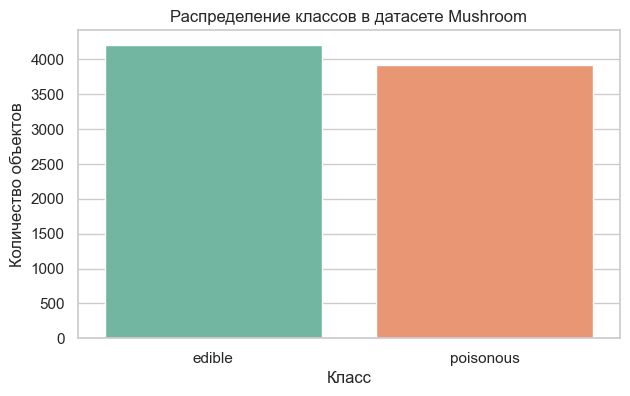

In [4]:
print("Информация о датасете:")
df.info()

print("\nКоличество пропусков по столбцам:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nРаспределение целевой переменной:")
class_distribution = df["class_label"].value_counts().rename_axis("class").reset_index(name="count")
class_distribution["share"] = class_distribution["count"] / len(df)
display(class_distribution.assign(share=class_distribution["share"].round(3)))

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="class_label", order=["edible", "poisonous"], palette="Set2")
plt.title("Распределение классов в датасете Mushroom")
plt.xlabel("Класс")
plt.ylabel("Количество объектов")
plt.show()
        


### 4. Блок с предварительной обработкой датасета

Все признаки в датасете являются категориальными. Поэтому перед обучением они преобразуются методом one-hot encoding: каждое возможное значение категориального признака превращается в отдельный бинарный столбец. Целевая переменная преобразуется в числа: `edible = 0`, `poisonous = 1`.

Данные делятся на обучающую и тестовую выборки со стратификацией, чтобы сохранить исходный баланс классов.
        


In [5]:
X = df.drop(columns=["class", "class_label"])
y = df["class"].map({"e": 0, "p": 1})

categorical_features = X.columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("cat", make_one_hot_encoder(), categorical_features),
    ],
    remainder="drop",
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print("\nДоля классов в обучающей выборке:")
display(y_train.map({0: "edible", 1: "poisonous"}).value_counts(normalize=True).round(3).to_frame("share"))
print("\nДоля классов в тестовой выборке:")
display(y_test.map({0: "edible", 1: "poisonous"}).value_counts(normalize=True).round(3).to_frame("share"))
        


Размер обучающей выборки: (6499, 22)
Размер тестовой выборки: (1625, 22)

Доля классов в обучающей выборке:


,share
class,
edible,0.518
poisonous,0.482



Доля классов в тестовой выборке:


,share
class,
edible,0.518
poisonous,0.482


### 5. Блок с тепловой картой

Так как исходные признаки категориальные, обычная корреляционная матрица по исходным столбцам неинформативна. Поэтому сначала признаки кодируются one-hot методом, после чего выбираются бинарные индикаторы, сильнее всего связанные с целевой переменной. Тепловая карта показывает связь между этими индикаторами и классом гриба.
        


Закодированные признаки с наибольшей абсолютной корреляцией с целевой переменной:


,corr_with_target
odor_n,-0.786
odor_f,0.624
stalk_surface_above_ring_k,0.588
stalk_surface_below_ring_k,0.574
ring_type_p,-0.540
gill_size_n,0.540
gill_size_b,-0.540
gill_color_b,0.539
bruises_t,-0.502
bruises_f,0.502


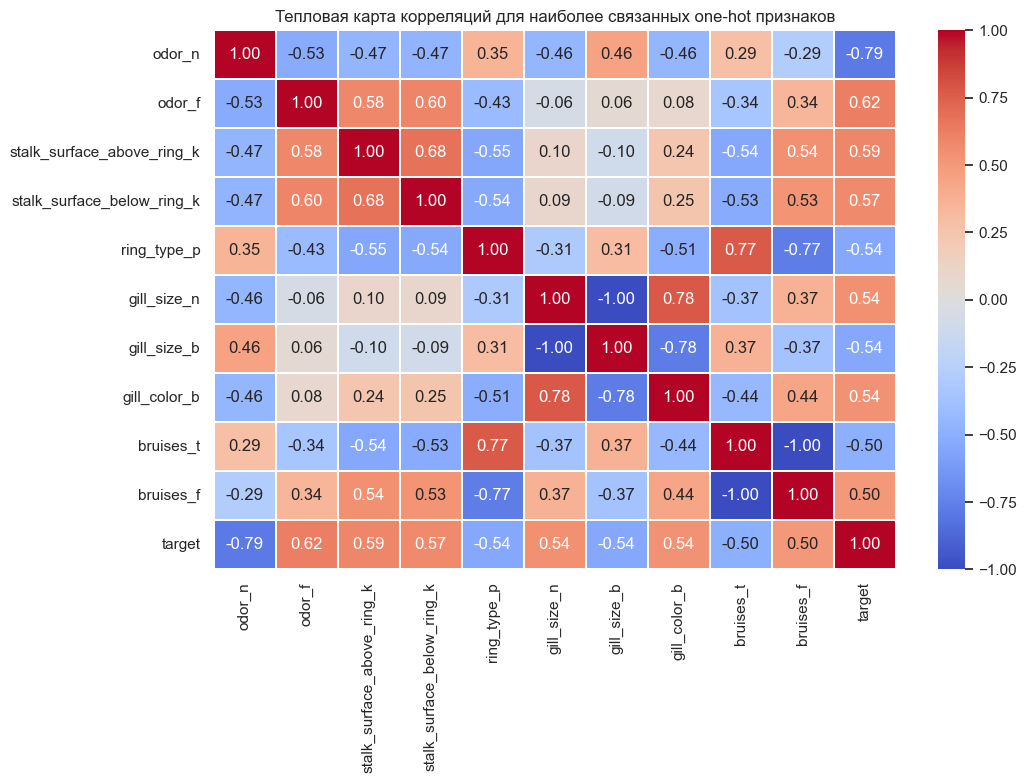

In [6]:
encoded = pd.get_dummies(X, drop_first=False)
encoded["target"] = y

target_corr = (
    encoded.corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values(key=lambda values: values.abs(), ascending=False)
)
top_encoded_features = target_corr.head(10).index.tolist()

print("Закодированные признаки с наибольшей абсолютной корреляцией с целевой переменной:")
display(target_corr.head(10).round(3).to_frame("corr_with_target"))

plt.figure(figsize=(11, 7))
sns.heatmap(
    encoded[top_encoded_features + ["target"]].corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.3,
)
plt.title("Тепловая карта корреляций для наиболее связанных one-hot признаков")
plt.show()
        


### 6. Блок с обучением модели

Модель строится как конвейер из кодирования категориальных признаков и нейронной сети. Используется многослойный перцептрон с двумя скрытыми слоями `(64, 32)`, функцией активации `relu`, оптимизатором `adam`, регуляризацией `alpha` и ранней остановкой. Ранняя остановка завершает обучение, когда качество на внутренней валидационной выборке перестает улучшаться.
        


In [7]:
mlp_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            MLPClassifier(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                solver="adam",
                alpha=0.001,
                learning_rate_init=0.001,
                max_iter=300,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=20,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

mlp_pipeline.fit(X_train, y_train)

mlp_model = mlp_pipeline.named_steps["model"]
print(f"Количество выполненных эпох обучения: {mlp_model.n_iter_}")
print(f"Итоговое значение функции потерь: {mlp_model.loss_:.4f}")
print(f"Лучшая внутренняя validation score: {mlp_model.best_validation_score_:.4f}")
        


Количество выполненных эпох обучения: 27
Итоговое значение функции потерь: 0.0005
Лучшая внутренняя validation score: 1.0000


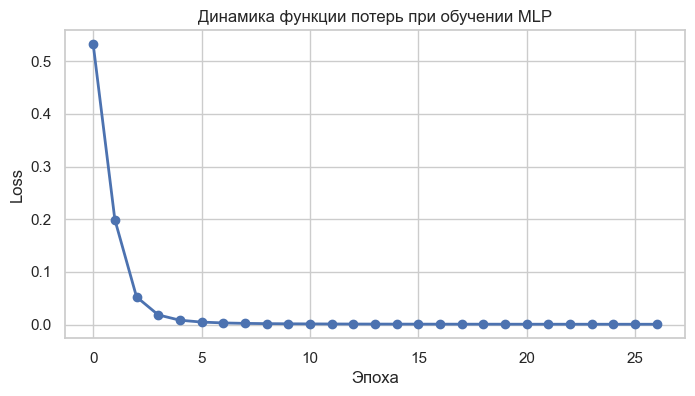

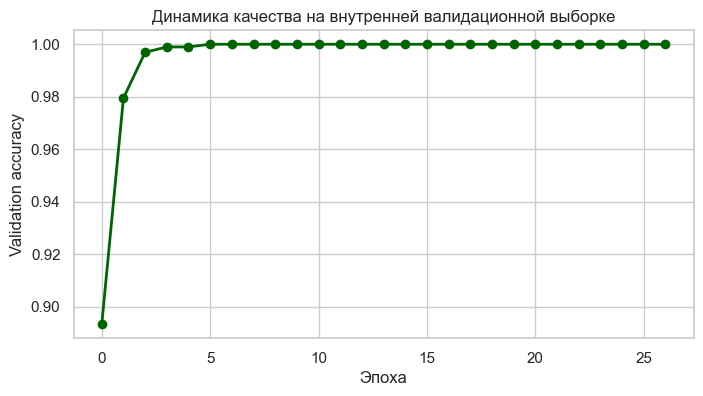

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(mlp_model.loss_curve_, marker="o", linewidth=2)
plt.title("Динамика функции потерь при обучении MLP")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(mlp_model.validation_scores_, marker="o", color="darkgreen", linewidth=2)
plt.title("Динамика качества на внутренней валидационной выборке")
plt.xlabel("Эпоха")
plt.ylabel("Validation accuracy")
plt.grid(True)
plt.show()
        


### 7. Блок с оценкой качества модели

Так как классы распределены почти равномерно, accuracy уже является достаточно показательной метрикой. Дополнительно рассчитываются precision, recall, F1-мера и ROC-AUC, а также строятся матрица ошибок и ROC-кривая.
        


In [9]:
y_pred = mlp_pipeline.predict(X_test)
y_proba = mlp_pipeline.predict_proba(X_test)[:, 1]

metrics = pd.DataFrame(
    {
        "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
        "value": [
            accuracy_score(y_test, y_pred),
            precision_score(y_test, y_pred),
            recall_score(y_test, y_pred),
            f1_score(y_test, y_pred),
            roc_auc_score(y_test, y_proba),
        ],
    }
)

display(metrics.assign(value=metrics["value"].round(4)))

print("Отчет по классам:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["edible", "poisonous"],
        digits=4,
    )
)
        


,metric,value
0,accuracy,0.9994
1,precision,1.0000
2,recall,0.9987
3,f1,0.9994
4,roc_auc,1.0000


Отчет по классам:
              precision    recall  f1-score   support

      edible     0.9988    1.0000    0.9994       842
   poisonous     1.0000    0.9987    0.9994       783

    accuracy                         0.9994      1625
   macro avg     0.9994    0.9994    0.9994      1625
weighted avg     0.9994    0.9994    0.9994      1625



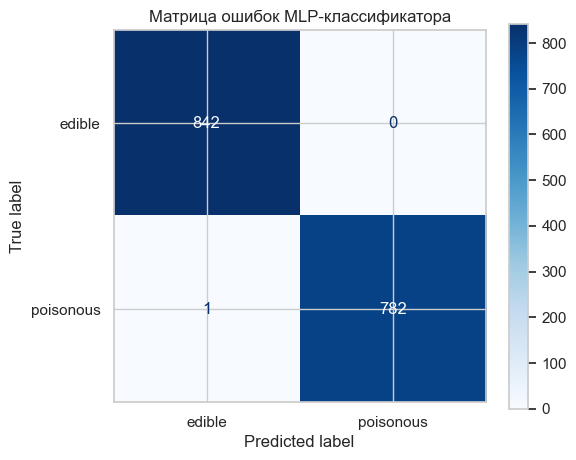

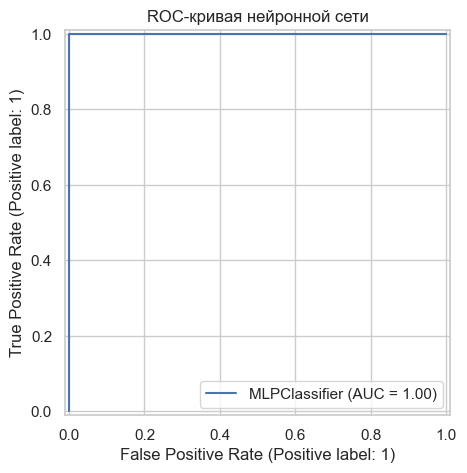

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["edible", "poisonous"],
    cmap="Blues",
    ax=ax,
)
plt.title("Матрица ошибок MLP-классификатора")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test,
    y_proba,
    name="MLPClassifier",
    ax=ax,
)
plt.title("ROC-кривая нейронной сети")
plt.grid(True)
plt.show()
        


### 8. Блок с анализом параметров модели

Ниже проверяется влияние коэффициента регуляризации `alpha`. Если регуляризация слишком слабая, модель может переобучиться; если слишком сильная — недообучиться. Сравнение выполняется по F1-мере на кросс-валидации.
        


,alpha,train_f1_mean,valid_f1_mean,valid_f1_std
0,0.0001,0.9997,0.9982,0.0009
1,0.0010,0.9997,0.9982,0.0009
2,0.0100,0.9997,0.9982,0.0009
3,0.1000,0.9997,0.9982,0.0009


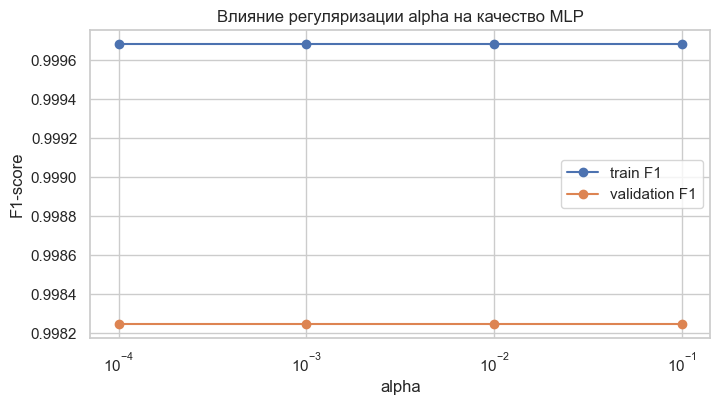

In [11]:
alpha_values = np.array([0.0001, 0.001, 0.01, 0.1])

validation_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            MLPClassifier(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                solver="adam",
                learning_rate_init=0.001,
                max_iter=250,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=15,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

train_scores, valid_scores = validation_curve(
    validation_pipeline,
    X_train,
    y_train,
    param_name="model__alpha",
    param_range=alpha_values,
    cv=3,
    scoring="f1",
    n_jobs=1,
)

validation_results = pd.DataFrame(
    {
        "alpha": alpha_values,
        "train_f1_mean": train_scores.mean(axis=1),
        "valid_f1_mean": valid_scores.mean(axis=1),
        "valid_f1_std": valid_scores.std(axis=1),
    }
)
display(validation_results.round(4))

plt.figure(figsize=(8, 4))
plt.semilogx(alpha_values, train_scores.mean(axis=1), marker="o", label="train F1")
plt.semilogx(alpha_values, valid_scores.mean(axis=1), marker="o", label="validation F1")
plt.title("Влияние регуляризации alpha на качество MLP")
plt.xlabel("alpha")
plt.ylabel("F1-score")
plt.legend()
plt.grid(True)
plt.show()
        


### 9. Блок с кривой обучения

Кривая обучения показывает, как меняется качество модели при увеличении количества обучающих объектов. Если валидационное качество быстро выходит на высокий уровень, значит данных достаточно для устойчивого обучения выбранной модели.
        


,train_size,train_f1_mean,valid_f1_mean,valid_f1_std
0,866,0.9926,0.9848,0.0034
1,1732,0.9996,0.9968,0.0029
2,2599,0.9992,0.9979,0.0005
3,3465,1.0000,0.9987,0.0010
4,4332,0.9996,0.9987,0.0010


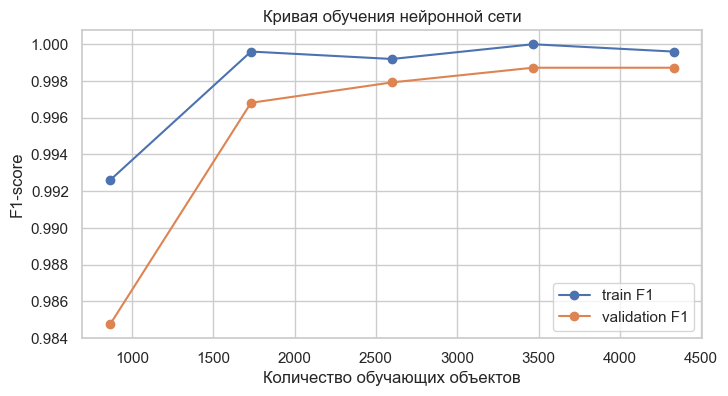

In [12]:
train_sizes, lc_train_scores, lc_valid_scores = learning_curve(
    mlp_pipeline,
    X_train,
    y_train,
    train_sizes=np.linspace(0.2, 1.0, 5),
    cv=3,
    scoring="f1",
    n_jobs=1,
)

learning_results = pd.DataFrame(
    {
        "train_size": train_sizes,
        "train_f1_mean": lc_train_scores.mean(axis=1),
        "valid_f1_mean": lc_valid_scores.mean(axis=1),
        "valid_f1_std": lc_valid_scores.std(axis=1),
    }
)
display(learning_results.round(4))

plt.figure(figsize=(8, 4))
plt.plot(train_sizes, lc_train_scores.mean(axis=1), marker="o", label="train F1")
plt.plot(train_sizes, lc_valid_scores.mean(axis=1), marker="o", label="validation F1")
plt.title("Кривая обучения нейронной сети")
plt.xlabel("Количество обучающих объектов")
plt.ylabel("F1-score")
plt.legend()
plt.grid(True)
plt.show()
        


### 10. Блок с оценкой важности признаков

Для интерпретации модели используется permutation importance. Метод перемешивает значения каждого исходного признака в тестовой выборке и оценивает, насколько падает F1-мера. Чем сильнее ухудшается качество, тем важнее признак для обученной модели.
        


,feature,importance_mean,importance_std
4,odor,0.0555,0.0023
7,gill_size,0.0085,0.0021
19,spore_print_color,0.0049,0.0015
8,gill_color,0.0023,0.0006
6,gill_spacing,0.0023,0.0003
10,stalk_root,0.0022,0.0005
2,cap_color,0.0015,0.0003
20,population,0.0010,0.0008
14,stalk_color_below_ring,0.0008,0.0005
21,habitat,0.0006,0.0008


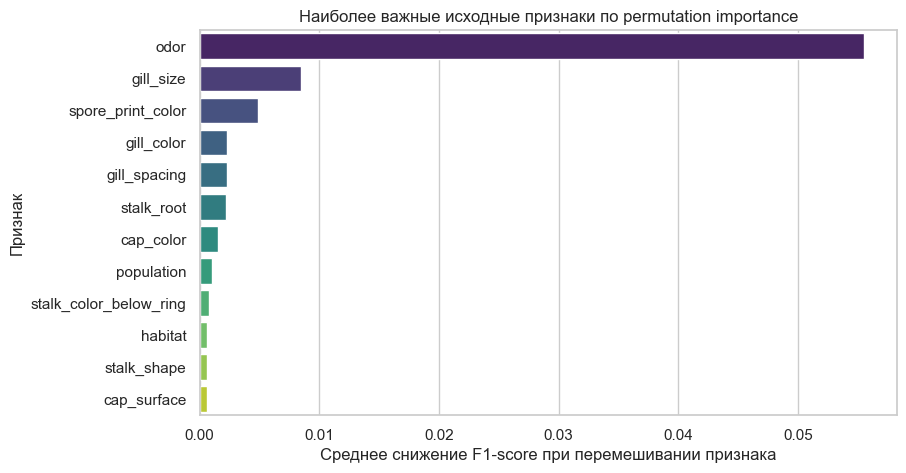

In [13]:
importance = permutation_importance(
    mlp_pipeline,
    X_test,
    y_test,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="f1",
    n_jobs=1,
)

importance_df = (
    pd.DataFrame(
        {
            "feature": X.columns,
            "importance_mean": importance.importances_mean,
            "importance_std": importance.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .head(12)
)

display(importance_df.round(4))

plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df, x="importance_mean", y="feature", palette="viridis")
plt.title("Наиболее важные исходные признаки по permutation importance")
plt.xlabel("Среднее снижение F1-score при перемешивании признака")
plt.ylabel("Признак")
plt.show()
        


### 11. Вывод

В лабораторной работе была реализована нейронная сеть прямого распространения для бинарной классификации на датасете **Mushroom**. Набор содержит **8124 объекта** и имеет почти равномерное распределение классов, поэтому модель оценивается без проблемы доминирования одного класса.

Категориальные признаки были преобразованы методом one-hot encoding, после чего обучен многослойный перцептрон. Модель показала высокое качество на тестовой выборке по accuracy, precision, recall, F1-score и ROC-AUC. Графики функции потерь и внутренней валидации показывают успешную сходимость обучения, а permutation importance помогает определить наиболее значимые признаки для классификации грибов.
        
